In [2]:
#Reading iOS csv:
import pandas as pd
android_data = pd.read_csv("../Processed_Data/Full_Datasets/android_data.csv")

**Android Preprocessing**

In [3]:
#Preparing dataset for analysis:
#Select relevant columns for analysis:
y = android_data['stress']
X = android_data.drop(columns=['stress', 'uid', 'day'])  # Drop target, ID columns, and date
print("Final feature set columns:", X.columns)
print("Final feature set shape:", X.shape)  

Final feature set columns: Index(['Unnamed: 0', 'pam', 'phq4-1', 'phq4-2', 'phq4-3', 'phq4-4',
       'phq4_resp_mean', 'phq4_resp_median', 'phq4_score', 'social_level',
       ...
       'sleep_heathkit_dur', 'gender', 'race_alaskan native/white',
       'race_american indian/alaska native', 'race_american indian/white',
       'race_asian', 'race_black', 'race_more than one', 'race_other/hispanic',
       'race_white'],
      dtype='str', length=184)
Final feature set shape: (7256, 184)


In [4]:
#Print out all of the features that are empty due to lack of collection for Android devices:
empty_cols = X.columns[X.isna().all()]
print(empty_cols)

Index(['other_playing_duration_ep_0', 'other_playing_duration_ep_1',
       'other_playing_duration_ep_2', 'other_playing_duration_ep_3',
       'other_playing_num_ep_0', 'other_playing_num_ep_1',
       'other_playing_num_ep_2', 'other_playing_num_ep_3',
       'sleep_heathkit_dur'],
      dtype='str')


In [5]:
# android missing features are all NaN, so we can drop those columns before modeling:
X = X.dropna(axis=1, how='all')

In [6]:
#Splitting data into test and train sets to prevent data leakage:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

#Column that identifies groups (participants):
group_col = 'uid'

#80/20 training testing split, with one testing group:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=android_data[group_col]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = android_data[group_col].iloc[train_idx]

#Checking stress label distribution to ensure the groups are stratified:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
stress
2.0    0.345873
3.0    0.253521
1.0    0.253165
4.0    0.110537
5.0    0.036905
Name: proportion, dtype: float64

Test distribution:
stress
3.0    0.295689
2.0    0.282332
1.0    0.239830
4.0    0.100182
5.0    0.081967
Name: proportion, dtype: float64


In [7]:
#Checking to see how many unique stress levels each participant has in the merged dataset:
android_data.groupby("uid")["stress"].nunique().value_counts()

stress
5    23
4     9
3     1
Name: count, dtype: int64

In [8]:
#Splitting training set into groups with StratifiedGroupKFold:
gkf = StratifiedGroupKFold(n_splits=5)

**Feature Selection**

In [9]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

#Cross-validation loop for ElasticNet regression with median imputation and standardization:

mae_scores = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    #Pipeline with median imputation and ElasticNet regression:
    EN_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("elasticnet", ElasticNet(
            alpha=0.1,
            l1_ratio=0.3,
            max_iter=5000,
            random_state=42)
        )
    ])
    
    EN_model.fit(X_tr, y_tr)
    
    preds = EN_model.predict(X_val)
    mae_scores.append(mean_absolute_error(y_val, preds))

print("ElasticNet CV MAE:", np.mean(mae_scores))
    

ElasticNet CV MAE: 0.6729691397215757


In [10]:
#Extracting feature importance from the ElasticNet model:
elastic = EN_model.named_steps["elasticnet"]
coefs = elastic.coef_
feature_names = X_train.columns

#Create a dataframe to display feature names and their corresponding coefficients:
EN_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

EN_importance["abs_coef"] = EN_importance["coefficient"].abs()
EN_importance = EN_importance.sort_values(by="abs_coef", ascending=False)

print(EN_importance.head(20))

                          feature  coefficient  abs_coef
10                         sse3-1     0.209050  0.209050
1                             pam    -0.179679  0.179679
12                         sse3-3    -0.158568  0.158568
13                         sse3-4    -0.114143  0.114143
2                          phq4-1     0.091735  0.091735
8                      phq4_score     0.045221  0.045221
85                light_mean_ep_3     0.042882  0.042882
117             loc_self_dorm_dur     0.041097  0.041097
48             audio_amp_std_ep_2    -0.033713  0.033713
37                 act_still_ep_3     0.029863  0.029863
5                          phq4-4     0.027869  0.027869
3                          phq4-2     0.026606  0.026606
44            audio_amp_mean_ep_2    -0.025310  0.025310
98                   loc_food_dur     0.022752  0.022752
18            act_in_vehicle_ep_0    -0.020042  0.020042
171                    race_black     0.017555  0.017555
49             audio_amp_std_ep

In [11]:
#List of non-zero coefficients (indicate features that contribute to the model's predictions):
selected_features = EN_importance[EN_importance["coefficient"] != 0]
print(selected_features)

                          feature  coefficient  abs_coef
10                         sse3-1     0.209050  0.209050
1                             pam    -0.179679  0.179679
12                         sse3-3    -0.158568  0.158568
13                         sse3-4    -0.114143  0.114143
2                          phq4-1     0.091735  0.091735
8                      phq4_score     0.045221  0.045221
85                light_mean_ep_3     0.042882  0.042882
117             loc_self_dorm_dur     0.041097  0.041097
48             audio_amp_std_ep_2    -0.033713  0.033713
37                 act_still_ep_3     0.029863  0.029863
5                          phq4-4     0.027869  0.027869
3                          phq4-2     0.026606  0.026606
44            audio_amp_mean_ep_2    -0.025310  0.025310
98                   loc_food_dur     0.022752  0.022752
18            act_in_vehicle_ep_0    -0.020042  0.020042
171                    race_black     0.017555  0.017555
49             audio_amp_std_ep

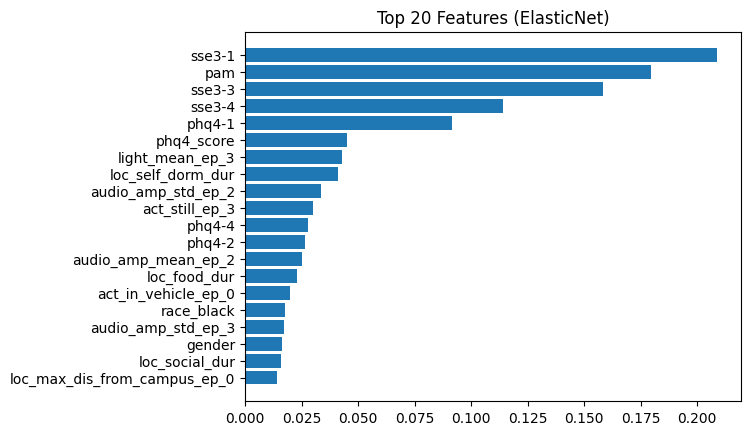

In [12]:
import matplotlib.pyplot as plt

#Visualize the top 20 most important features based on absolute coefficient values:
top = EN_importance.head(20)
plt.figure()
plt.barh(top["feature"], top["abs_coef"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (ElasticNet)")
plt.show()

In [13]:
#XGBoost regression with median imputation and standardization:
from xgboost import XGBRegressor

mae_scores_xgb = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    XGBR_model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    XGBR_model.fit(X_tr.values, y_tr.values)
    
    preds = XGBR_model.predict(X_val.values)
    mae_scores_xgb.append(mean_absolute_error(y_val, preds))

print("XGBoost CV MAE:", np.mean(mae_scores_xgb))

XGBoost CV MAE: 0.6762568680773913


In [14]:
#Final XGBoost model trained on the entire training set for feature importance:
final_XGBR_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_XGBR_model.fit(X_train.values, y_train.values)

#Feature importance from XGBoost model:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": XGBR_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="importance", ascending=False)

xgb_importance.head(20)

,feature,importance
13,sse3-4,0.088624
12,sse3-3,0.069391
8,phq4_score,0.055580
10,sse3-1,0.042927
1,pam,0.026887
18,act_in_vehicle_ep_0,0.016647
5,phq4-4,0.011725
174,race_white,0.011152
3,phq4-2,0.010910
114,loc_self_dorm_audio_voice,0.010543


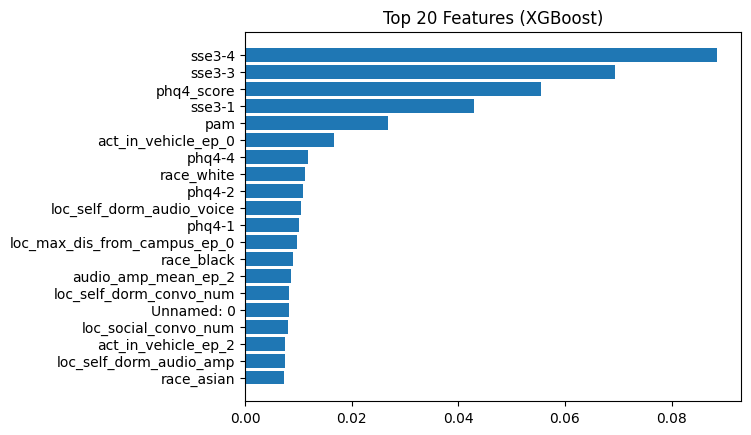

In [15]:
#Visualize the top 20 most important features from the XGBoost model:
top = xgb_importance.head(20)

plt.figure()
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (XGBoost)")
plt.show()

In [23]:
#Merge results from ElasticNet and XGBoost to see which features are important in both models:
android_merged_importance = pd.merge(
    EN_importance[["feature", "coefficient"]],
    xgb_importance[["feature", "importance"]],
    on="feature",
    how="inner"
)

#Normalize importance values for better comparison:
android_merged_importance["coef_norm"] = android_merged_importance["coefficient"].abs() / android_merged_importance["coefficient"].abs().max()
android_merged_importance["xgb_norm"] = android_merged_importance["importance"] / android_merged_importance["importance"].max()

#Create a combined importance score by averaging the normalized values from both models:
android_merged_importance["combined_score"] = (android_merged_importance["coef_norm"] + android_merged_importance["xgb_norm"]) / 2

#Keep only relevant columns and sort by combined score:
android_merged_importance = android_merged_importance[["feature", "coef_norm", "xgb_norm", "combined_score"]]
android_merged_importance = android_merged_importance.sort_values(by="combined_score", ascending=False)

print(android_merged_importance.head(50))

                           feature  coef_norm  xgb_norm  combined_score
3                           sse3-4   0.546009  1.000000        0.773005
2                           sse3-3   0.758515  0.782988        0.770751
0                           sse3-1   1.000000  0.484374        0.742187
1                              pam   0.859501  0.303385        0.581443
5                       phq4_score   0.216317  0.627146        0.421732
4                           phq4-1   0.438817  0.114721        0.276769
14             act_in_vehicle_ep_0   0.095870  0.187838        0.141854
6                  light_mean_ep_3   0.205130  0.061451        0.133291
10                          phq4-4   0.133310  0.132302        0.132806
11                          phq4-2   0.127269  0.123106        0.125187
7                loc_self_dorm_dur   0.196588  0.052718        0.124653
8               audio_amp_std_ep_2   0.161266  0.063030        0.112148
12             audio_amp_mean_ep_2   0.121069  0.096567        0

In [25]:
#Preserving protected attributes in the feature selection process:
#Preserving race and gender:
protected_cols = [col for col in X.columns if "race_" in col or "gender" in col]
print(protected_cols)

['race_american indian/alaska native', 'race_american indian/white', 'race_asian', 'race_black', 'race_more than one', 'gender', 'race_alaskan native/white', 'race_white', 'race_other/hispanic']


In [26]:
#Selecting features that have a combined importance score above a threshold of 0.02:
android_selected_features = android_merged_importance[
    android_merged_importance["combined_score"] > 0.1
]["feature"]

print("Number of selected features:", len(android_selected_features))

Number of selected features: 14


In [27]:
#Combining featuers selected by the models with protected attributes to create the final feature set for modeling:
android_final_features = list(set(android_selected_features) | set(protected_cols))

In [28]:
#Reducing the feature set to only the selected features for modeling:
#Printing shape of X after feature selection to confirm the number of features has been reduced:
X = X[android_final_features]
print("Shape of X after feature selection:", X.shape)

Shape of X after feature selection: (7256, 23)


In [29]:
#Create a new dataframe with the selected features for future modeling:
X_selected = X[android_final_features]
final_df = X_selected.copy()
final_df["stress"] = y
final_df["uid"] = android_data["uid"]  # Add participant ID back for modeling
final_df["day"] = android_data["day"]  # Add day column back for modeling

final_df.to_csv("../Processed_Data/android_SelectedFeatures.csv")